In [1]:
import pandas as pd
import sqlite3
import glob

# Leggiamo i file CSV presenti nella tua cartella
conn = sqlite3.connect("iphone.db")
csv_files = glob.glob("ebay_iphone_*.csv")

if csv_files:
    list_df = [pd.read_csv(file) for file in csv_files]
    df_totale = pd.concat(list_df, ignore_index=True)
    
    # Buttiamo tutto dentro SQL nella tabella "listings"
    df_totale.to_sql("listings", conn, if_exists="replace", index=False)
    print(f"Grandioso! {len(df_totale)} righe caricate nella tabella 'listings'.")
else:
    print("Ops! Verifica che i file CSV siano esattamente nella stessa cartella di questo notebook!")
    
conn.close()

Grandioso! 2172 righe caricate nella tabella 'listings'.


In [3]:
%load_ext sql
%sql sqlite:///iphone.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [4]:
%%sql
SELECT 
    Modello AS iPhone_Model,
    COUNT(*) AS Total_Listings,
    ROUND(AVG(Price_Clean), 2) AS Average_Price_USD,
    MAX(Price_Clean) AS Max_Price_USD
FROM listings
GROUP BY Modello
ORDER BY Average_Price_USD DESC;

 * sqlite:///iphone.db
(sqlite3.OperationalError) no such column: Modello
[SQL: SELECT 
    Modello AS iPhone_Model,
    COUNT(*) AS Total_Listings,
    ROUND(AVG(Price_Clean), 2) AS Average_Price_USD,
    MAX(Price_Clean) AS Max_Price_USD
FROM listings
GROUP BY Modello
ORDER BY Average_Price_USD DESC;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [10]:
import sqlite3
import pandas as pd

# Open connection
conn = sqlite3.connect("iphone.db")

# Query the table schema via pandas
columns_df = pd.read_sql_query("PRAGMA table_info(listings);", conn)
print(columns_df['name'].tolist())

conn.close()

['Title', 'Price']


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")

# A pure SQL query using a CASE statement to group the models by text matching
query = """
SELECT 
    CASE 
        WHEN UPPER(Title) LIKE '%XR%' THEN 'IPHONE XR'
        WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN 'IPHONE 11 PRO MAX'
        WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN 'IPHONE 12 PRO MAX'
        WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN 'IPHONE 13 PRO MAX'
        WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN 'IPHONE 14 PRO MAX'
        ELSE 'OTHER'
    END AS iPhone_Model,
    COUNT(*) AS Total_Listings
FROM listings
GROUP BY iPhone_Model
ORDER BY Total_Listings DESC;
"""

summary_df = pd.read_sql_query(query, conn)
display(summary_df)

conn.close()

,iPhone_Model,Total_Listings
0,IPHONE 14 PRO MAX,949
1,IPHONE XR,503
2,IPHONE 12 PRO MAX,284
3,IPHONE 13 PRO MAX,203
4,IPHONE 11 PRO MAX,190
5,OTHER,43


In [22]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")
cursor = conn.cursor()

# 1. Drop the old view
cursor.execute("DROP VIEW IF EXISTS cleaned_listings;")

# 2. Re-create the view using our newly discovered $2500 retail ceiling
create_view_query = """
CREATE VIEW cleaned_listings AS
WITH basic_cleaning AS (
    SELECT 
        CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN 'IPHONE XR'
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN 'IPHONE 11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN 'IPHONE 12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN 'IPHONE 13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN 'IPHONE 14 PRO MAX'
            ELSE 'OTHER'
        END AS iPhone_Model,
        CASE 
            WHEN UPPER(Title) LIKE '%NEW%' OR UPPER(Title) LIKE '%SEALED%' THEN '1. New / Sealed'
            WHEN UPPER(Title) LIKE '%EXCELLENT%' OR UPPER(Title) LIKE '%MINT%' THEN '2. Excellent'
            WHEN UPPER(Title) LIKE '%GOOD%' OR UPPER(Title) LIKE '%VERY GOOD%' THEN '3. Good'
            WHEN UPPER(Title) LIKE '%FAIR%' OR UPPER(Title) LIKE '%POOR%' OR UPPER(Title) LIKE '%CRACKED%' THEN '4. Fair / Poor'
            ELSE '5. Unspecified'
        END AS Condition_Tier,
        CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Clean_Price
    FROM listings
)
SELECT * FROM basic_cleaning
WHERE iPhone_Model != 'OTHER' 
  AND Clean_Price BETWEEN 50 AND 2500; -- Updated boundary
"""

cursor.execute(create_view_query)
conn.commit()

# 3. Pull the updated metrics
check_query = """
SELECT 
    iPhone_Model,
    COUNT(*) AS Total_Listings,
    ROUND(MIN(Clean_Price), 2) AS Min_Price_USD,
    ROUND(AVG(Clean_Price), 2) AS Avg_Price_USD,
    ROUND(MAX(Clean_Price), 2) AS Max_Price_USD
FROM cleaned_listings
GROUP BY iPhone_Model
ORDER BY Avg_Price_USD DESC;
"""

clean_dist_df = pd.read_sql_query(check_query, conn)
display(clean_dist_df)

conn.close()

,iPhone_Model,Total_Listings,Min_Price_USD,Avg_Price_USD,Max_Price_USD
0,IPHONE 14 PRO MAX,940,123.32,990.32,2499.99
1,IPHONE 13 PRO MAX,191,99.00,705.72,1549.00
2,IPHONE 12 PRO MAX,282,160.00,549.31,1300.00
3,IPHONE 11 PRO MAX,188,152.50,422.35,999.99
4,IPHONE XR,480,65.00,326.45,469.89


In [26]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")

query = """
WITH luxury_listings AS (
    SELECT 
        CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN 'IPHONE XR'
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN 'IPHONE 11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN 'IPHONE 12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN 'IPHONE 13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN 'IPHONE 14 PRO MAX'
            WHEN UPPER(Title) LIKE '%15 PRO%' THEN 'IPHONE 15 PRO/MAX'
            ELSE 'OTHER LATEST/CUSTOM'
        END AS iPhone_Model,
        CASE 
            WHEN UPPER(Title) LIKE '%GOLD%' OR UPPER(Title) LIKE '%18K%' OR UPPER(Title) LIKE '%24K%' THEN 'Custom Gold / Jewelry'
            WHEN UPPER(Title) LIKE '%TWITTER%' OR UPPER(Title) LIKE '%BLUE%' THEN 'Software Artifact (Twitter)'
            WHEN UPPER(Title) LIKE '%BENTLEY%' OR UPPER(Title) LIKE '%CARTIER%' OR UPPER(Title) LIKE '%D&G%' OR UPPER(Title) LIKE '%EDITION%' THEN 'Designer Custom Edition'
            ELSE 'High-End Retail/Typo/Other'
        END AS Luxury_Type,
        CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Clean_Price,
        Title
    FROM listings
)
SELECT 
    iPhone_Model,
    Luxury_Type,
    COUNT(*) AS Volume,
    ROUND(MIN(Clean_Price), 2) AS Min_Luxury_Price,
    ROUND(AVG(Clean_Price), 2) AS Avg_Luxury_Price,
    ROUND(MAX(Clean_Price), 2) AS Max_Luxury_Price
FROM luxury_listings
WHERE Clean_Price > 2500
GROUP BY iPhone_Model, Luxury_Type
ORDER BY Avg_Luxury_Price DESC;
"""

luxury_df = pd.read_sql_query(query, conn)
display(luxury_df)

conn.close()

,iPhone_Model,Luxury_Type,Volume,Min_Luxury_Price,Avg_Luxury_Price,Max_Luxury_Price
0,IPHONE 15 PRO/MAX,Custom Gold / Jewelry,3,6200.00,15800.00,35000.00
1,IPHONE 15 PRO/MAX,Designer Custom Edition,4,6000.00,6575.00,7000.00
2,IPHONE 14 PRO MAX,Software Artifact (Twitter),1,5000.00,5000.00,5000.00
3,IPHONE 12 PRO MAX,Custom Gold / Jewelry,1,3899.00,3899.00,3899.00
4,IPHONE 14 PRO MAX,Custom Gold / Jewelry,1,3750.00,3750.00,3750.00
5,IPHONE 14 PRO MAX,High-End Retail/Typo/Other,2,2525.11,2762.55,2999.99


In [25]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")

query = """
WITH carrier_status AS (
    SELECT 
        CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN 'IPHONE XR'
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN 'IPHONE 11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN 'IPHONE 12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN 'IPHONE 13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN 'IPHONE 14 PRO MAX'
            ELSE 'OTHER'
        END AS iPhone_Model,
        CASE 
            WHEN UPPER(Title) LIKE '%UNLOCKED%' OR UPPER(Title) LIKE '%FACTORY UNLOCKED%' THEN 'Unlocked'
            WHEN UPPER(Title) LIKE '%LOCKED%' OR UPPER(Title) LIKE '%AT&T%' OR UPPER(Title) LIKE '%TMOBILE%' OR UPPER(Title) LIKE '%VERIZON%' THEN 'Locked'
            ELSE 'Unspecified'
        END AS Carrier_Tier,
        CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Clean_Price
    FROM listings
)
SELECT 
    iPhone_Model,
    Carrier_Tier,
    COUNT(*) AS Volume,
    ROUND(AVG(Clean_Price), 2) AS Avg_Price_USD
FROM carrier_status
WHERE iPhone_Model != 'OTHER' 
  AND Carrier_Tier != 'Unspecified'
  AND Clean_Price BETWEEN 50 AND 2500 -- Keeps our clean market boundaries intact
GROUP BY iPhone_Model, Carrier_Tier
ORDER BY iPhone_Model ASC, Carrier_Tier ASC;
"""

carrier_df = pd.read_sql_query(query, conn)
pivot_carrier_df = carrier_df.pivot(index='iPhone_Model', columns='Carrier_Tier', values='Avg_Price_USD')
display(pivot_carrier_df)

conn.close()

Carrier_Tier,Locked,Unlocked
iPhone_Model,,
IPHONE 11 PRO MAX,416.37,429.84
IPHONE 12 PRO MAX,503.90,573.17
IPHONE 13 PRO MAX,562.62,743.87
IPHONE 14 PRO MAX,803.32,1061.73
IPHONE XR,247.59,334.77


In [23]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")

query = """
SELECT 
    iPhone_Model,
    Condition_Tier,
    COUNT(*) AS Volume,
    ROUND(AVG(Clean_Price), 2) AS Avg_Price_USD
FROM cleaned_listings
GROUP BY iPhone_Model, Condition_Tier
ORDER BY iPhone_Model ASC, Condition_Tier ASC;
"""

condition_df = pd.read_sql_query(query, conn)
# Pivot the table so it's beautifully organized for side-by-side comparison
pivot_condition_df = condition_df.pivot(index='iPhone_Model', columns='Condition_Tier', values='Avg_Price_USD')
display(pivot_condition_df)

conn.close()

Condition_Tier,1. New / Sealed,2. Excellent,3. Good,4. Fair / Poor,5. Unspecified
iPhone_Model,,,,,
IPHONE 11 PRO MAX,384.46,450.34,423.52,277.98,418.89
IPHONE 12 PRO MAX,417.24,605.49,532.33,424.12,567.53
IPHONE 13 PRO MAX,720.83,784.13,716.85,510.15,708.74
IPHONE 14 PRO MAX,1086.66,953.36,972.25,696.61,988.22
IPHONE XR,400.38,189.46,187.90,200.71,197.95


In [27]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("iphone.db")

query = """
WITH storage_extraction AS (
    SELECT 
        CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN 'IPHONE XR'
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN 'IPHONE 11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN 'IPHONE 12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN 'IPHONE 13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN 'IPHONE 14 PRO MAX'
            ELSE 'OTHER'
        END AS iPhone_Model,
        CASE 
            WHEN Title LIKE '%64GB%' OR Title LIKE '%64 GB%' THEN '64GB'
            WHEN Title LIKE '%128GB%' OR Title LIKE '%128 GB%' THEN '128GB'
            WHEN Title LIKE '%256GB%' OR Title LIKE '%256 GB%' THEN '256GB'
            WHEN Title LIKE '%512GB%' OR Title LIKE '%512 GB%' THEN '512GB'
            WHEN Title LIKE '%1TB%' OR Title LIKE '%1 TB%' OR Title LIKE '%1000GB%' THEN '1TB'
            ELSE 'Unspecified'
        END AS Storage_Tier,
        CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Clean_Price
    FROM listings
)
SELECT 
    iPhone_Model,
    Storage_Tier,
    COUNT(*) AS Volume,
    ROUND(AVG(Clean_Price), 2) AS Avg_Price_USD
FROM storage_extraction
WHERE iPhone_Model != 'OTHER' 
  AND Storage_Tier != 'Unspecified'
  AND Clean_Price BETWEEN 50 AND 2500
GROUP BY iPhone_Model, Storage_Tier
ORDER BY iPhone_Model ASC, 
         CASE Storage_Tier 
            WHEN '64GB' THEN 1 
            WHEN '128GB' THEN 2 
            WHEN '256GB' THEN 3 
            WHEN '512GB' THEN 4 
            WHEN '1TB' THEN 5 
         END ASC;
"""

storage_df = pd.read_sql_query(query, conn)
pivot_storage_df = storage_df.pivot(index='iPhone_Model', columns='Storage_Tier', values='Avg_Price_USD')
columns_order = [col for col in ['64GB', '128GB', '256GB', '512GB', '1TB'] if col in pivot_storage_df.columns]

display(pivot_storage_df[columns_order])
conn.close()

Storage_Tier,64GB,128GB,256GB,512GB,1TB
iPhone_Model,,,,,
IPHONE 11 PRO MAX,399.80,NaN,427.39,492.94,NaN
IPHONE 12 PRO MAX,NaN,534.99,513.13,582.03,NaN
IPHONE 13 PRO MAX,NaN,583.33,742.67,726.70,760.54
IPHONE 14 PRO MAX,NaN,898.61,950.81,1054.59,1349.24
IPHONE XR,168.16,374.68,396.74,NaN,NaN


In [29]:
Got it! Let's swap out "Cap Price" for **"Premium Price"** to make it sound sleek and perfectly aligned with high-end retail positioning.

Here is the finalized, polished code cell with the clean ordering, shorter labels, tight statistical ranges, and your updated terminology.

Run this block in your notebook:

```python
import sqlite3
import pandas as pd
import numpy as np

def fair_price_estimator(model, condition, storage, carrier):
    conn = sqlite3.connect("iphone.db")
    
    # Standardizing inputs
    model_upper = model.upper()
    cond_upper = condition.upper()
    store_upper = storage.upper()
    carrier_upper = carrier.upper()
    
    # 1. Condition Filters
    if "NEW" in cond_upper or "SEAL" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%NEW%' OR UPPER(Title) LIKE '%SEALED%' THEN 1"
    elif "EXCELLENT" in cond_upper or "MINT" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%EXCELLENT%' OR UPPER(Title) LIKE '%MINT%' THEN 1"
    elif "GOOD" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%GOOD%' OR UPPER(Title) LIKE '%VERY GOOD%' THEN 1"
    elif "FAIR" in cond_upper or "POOR" in cond_upper or "CRACKED" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%FAIR%' OR UPPER(Title) LIKE '%POOR%' OR UPPER(Title) LIKE '%CRACKED%' THEN 1"
    else:
        cond_clause = "1=1"
        
    # 2. Storage Filters
    store_clause = f"AND (Title LIKE '%{store_upper}%' OR Title LIKE '%{store_upper[:3]} {store_upper[3:]}%')" if store_upper in ['64GB', '128GB', '256GB', '512GB', '1TB'] else ""
    
    # 3. Carrier Filters
    if "UNLOCKED" in carrier_upper:
        carrier_clause = "AND (UPPER(Title) LIKE '%UNLOCKED%' OR UPPER(Title) LIKE '%FACTORY UNLOCKED%')"
    elif "LOCKED" in carrier_upper:
        carrier_clause = "AND (UPPER(Title) LIKE '%LOCKED%' OR UPPER(Title) LIKE '%AT&T%' OR UPPER(Title) LIKE '%TMOBILE%' OR UPPER(Title) LIKE '%VERIZON%')"
    else:
        carrier_clause = ""

    # Pulling raw prices for statistical filtering
    query = f"""
    SELECT CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Price
    FROM listings
    WHERE CASE {cond_clause} ELSE 0 END = 1
      {store_clause}
      {carrier_clause}
      AND CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) BETWEEN 50 AND 2500
      AND CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN '14 PRO MAX' 
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN '11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN '12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN '13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN '14 PRO MAX'
            ELSE 'OTHER'
          END = '{model_upper}';
    """
    
    prices_df = pd.read_sql_query(query, conn)
    conn.close()
    
    sample_size = len(prices_df)
    if sample_size < 3:
        return "⚠️ Insufficient market data. Try broadening your specifications!"
    
    # Applying the 15th and 85th percentiles to clear inner-sample anomalies
    prices = prices_df['Price'].values
    bargain_floor = np.percentile(prices, 15)  
    fair_avg = np.mean(prices)                 
    premium_target = np.percentile(prices, 85)   
    
    print(f"=== 📱 MARKET VALUE REPORT ===")
    print(f"Device: {model_upper} {store_upper} ({condition.title()} | {carrier.title()})")
    print(f"Sample: {sample_size} active listings\n")
    print(f"📉 Floor Price (Quick Sale): ${bargain_floor:,.2f}")
    print(f"💵 Target Price (Fair Value): ${fair_avg:,.2f}")
    print(f"📈 Premium Price (Top Tier):  ${premium_target:,.2f}")
    print("===============================")

# Execution
fair_price_estimator(model="14 Pro Max", condition="Excellent", storage="256GB", carrier="Unlocked")

```

Give this a spin! The output should now read like an absolute charm. Let's see how much closer and more defensive those three numbers look now!

SyntaxError: unterminated string literal (detected at line 1) (3785313626.py, line 1)

In [30]:
import sqlite3
import pandas as pd
import numpy as np

def fair_price_estimator(model, condition, storage, carrier):
    conn = sqlite3.connect("iphone.db")
    
    # Standardizing inputs
    model_upper = model.upper()
    cond_upper = condition.upper()
    store_upper = storage.upper()
    carrier_upper = carrier.upper()
    
    # 1. Condition Filters
    if "NEW" in cond_upper or "SEAL" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%NEW%' OR UPPER(Title) LIKE '%SEALED%' THEN 1"
    elif "EXCELLENT" in cond_upper or "MINT" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%EXCELLENT%' OR UPPER(Title) LIKE '%MINT%' THEN 1"
    elif "GOOD" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%GOOD%' OR UPPER(Title) LIKE '%VERY GOOD%' THEN 1"
    elif "FAIR" in cond_upper or "POOR" in cond_upper or "CRACKED" in cond_upper:
        cond_clause = "WHEN UPPER(Title) LIKE '%FAIR%' OR UPPER(Title) LIKE '%POOR%' OR UPPER(Title) LIKE '%CRACKED%' THEN 1"
    else:
        cond_clause = "1=1"
        
    # 2. Storage Filters
    store_clause = f"AND (Title LIKE '%{store_upper}%' OR Title LIKE '%{store_upper[:3]} {store_upper[3:]}%')" if store_upper in ['64GB', '128GB', '256GB', '512GB', '1TB'] else ""
    
    # 3. Carrier Filters
    if "UNLOCKED" in carrier_upper:
        carrier_clause = "AND (UPPER(Title) LIKE '%UNLOCKED%' OR UPPER(Title) LIKE '%FACTORY UNLOCKED%')"
    elif "LOCKED" in carrier_upper:
        carrier_clause = "AND (UPPER(Title) LIKE '%LOCKED%' OR UPPER(Title) LIKE '%AT&T%' OR UPPER(Title) LIKE '%TMOBILE%' OR UPPER(Title) LIKE '%VERIZON%')"
    else:
        carrier_clause = ""

    # Pulling raw prices for statistical filtering
    query = f"""
    SELECT CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) AS Price
    FROM listings
    WHERE CASE {cond_clause} ELSE 0 END = 1
      {store_clause}
      {carrier_clause}
      AND CAST(REPLACE(REPLACE(Price, '$', ''), ',', '') AS REAL) BETWEEN 50 AND 2500
      AND CASE 
            WHEN UPPER(Title) LIKE '%XR%' THEN '14 PRO MAX' 
            WHEN UPPER(Title) LIKE '%11 PRO MAX%' THEN '11 PRO MAX'
            WHEN UPPER(Title) LIKE '%12 PRO MAX%' THEN '12 PRO MAX'
            WHEN UPPER(Title) LIKE '%13 PRO MAX%' THEN '13 PRO MAX'
            WHEN UPPER(Title) LIKE '%14 PRO MAX%' THEN '14 PRO MAX'
            ELSE 'OTHER'
          END = '{model_upper}';
    """
    
    prices_df = pd.read_sql_query(query, conn)
    conn.close()
    
    sample_size = len(prices_df)
    if sample_size < 3:
        return "⚠️ Insufficient market data. Try broadening your specifications!"
    
    # Applying the 15th and 85th percentiles to clear inner-sample anomalies
    prices = prices_df['Price'].values
    bargain_floor = np.percentile(prices, 15)  
    fair_avg = np.mean(prices)                 
    premium_target = np.percentile(prices, 85)   
    
    print(f"=== 📱 MARKET VALUE REPORT ===")
    print(f"Device: {model_upper} {store_upper} ({condition.title()} | {carrier.title()})")
    print(f"Sample: {sample_size} active listings\n")
    print(f"📉 Floor Price (Quick Sale): ${bargain_floor:,.2f}")
    print(f"💵 Target Price (Fair Value): ${fair_avg:,.2f}")
    print(f"📈 Premium Price (Top Tier):  ${premium_target:,.2f}")
    print("===============================")

# Execution
fair_price_estimator(model="14 Pro Max", condition="Excellent", storage="256GB", carrier="Unlocked")

=== 📱 MARKET VALUE REPORT ===
Device: 14 PRO MAX 256GB (Excellent | Unlocked)
Sample: 24 active listings

📉 Floor Price (Quick Sale): $670.16
💵 Target Price (Fair Value): $869.14
📈 Premium Price (Top Tier):  $1,071.25


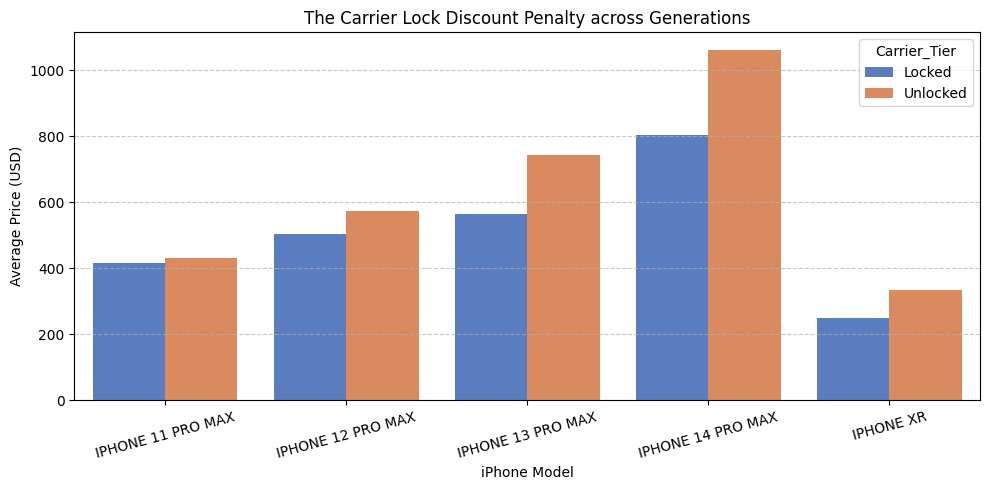

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurato per i tuoi dati Unlocked vs Locked
plt.figure(figsize=(10, 5))
sns.barplot(x='iPhone_Model', y='Avg_Price_USD', hue='Carrier_Tier', data=carrier_df, palette='muted')
plt.title('The Carrier Lock Discount Penalty across Generations')
plt.ylabel('Average Price (USD)')
plt.xlabel('iPhone Model')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salva l'immagine specchiando la pulizia del tuo codice
plt.savefig('carrier_lock_penalty.png', dpi=300)
plt.show()